# Import Dataset 

In [3]:
import pandas as pd

df = pd.read_csv(

    "soft_tissue_msk_2023_clinical_data.tsv",

    sep="\t"

)

Inspect Dataset. Specifically, column names, data types, first five rows, and missing values. 

In [4]:
print("Dataset shape:")

print(df.shape)

print("\nColumn names:")

print(df.columns.tolist())

print("\nData types:")

print(df.dtypes)

print("\nFirst five rows:")

display(df.head())

print("\nMissing values:")

display(df.isna().sum())

Dataset shape:
(42, 27)

Column names:
['Study ID', 'Patient ID', 'Sample ID', 'Age at Which Sequencing was Reported (Years)', 'Cancer Type', 'Cancer Type Detailed', 'Ethnicity Category', 'Fraction Genome Altered', 'Gene Panel', 'Institute Source', 'Metastatic Site', 'MSI Score', 'MSI Type', 'Mutation Count', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'Primary Tumor Site', 'Race Category', 'Sample Class', 'Number of Samples Per Patient', 'Sample coverage', 'Sample Type', 'Sex', 'Somatic Status', 'TMB (nonsynonymous)', 'Tumor Purity']

Data types:
Study ID                                         object
Patient ID                                       object
Sample ID                                        object
Age at Which Sequencing was Reported (Years)    float64
Cancer Type                                      object
Cancer Type Detailed                             object
Ethnicity Category                               object
Fraction Genome Altered  

,Study ID,Patient ID,Sample ID,Age at Which Sequencing was Reported (Years),Cancer Type,Cancer Type Detailed,Ethnicity Category,Fraction Genome Altered,Gene Panel,Institute Source,...,Primary Tumor Site,Race Category,Sample Class,Number of Samples Per Patient,Sample coverage,Sample Type,Sex,Somatic Status,TMB (nonsynonymous),Tumor Purity
0,soft_tissue_msk_2023,P-0006113,P-0006113-T01-IM5,18.0,Soft Tissue Sarcoma,Alveolar Rhabdomyosarcoma,"Spanish NOS; Hispanic NOS, Latino NOS",0.0844,IMPACT410,MSKCC,...,Soft Tissue,WHITE,Tumor,2,949,Primary,Male,Matched,0.978720,80.0
1,soft_tissue_msk_2023,P-0006113,P-0006113-T02-IM6,18.0,Soft Tissue Sarcoma,Alveolar Rhabdomyosarcoma,"Spanish NOS; Hispanic NOS, Latino NOS",0.3861,IMPACT468,MSKCC,...,Soft Tissue,WHITE,Tumor,2,743,Metastasis,Male,Matched,0.864698,30.0
2,soft_tissue_msk_2023,P-0013120,P-0013120-T04-IM6,19.0,Soft Tissue Sarcoma,Embryonal Rhabdomyosarcoma,Non-Spanish; Non-Hispanic,0.1217,IMPACT468,MSKCC,...,Soft Tissue,WHITE,Tumor,2,727,Metastasis,Female,Matched,0.000000,30.0
3,soft_tissue_msk_2023,P-0013120,P-0013120-T06-IM6,20.0,Soft Tissue Sarcoma,Embryonal Rhabdomyosarcoma,Non-Spanish; Non-Hispanic,0.2839,IMPACT468,NaN,...,Unknown,WHITE,Tumor,2,666,Metastasis,Female,Matched,0.000000,70.0
4,soft_tissue_msk_2023,P-0018770,P-0018770-T02-IM6,18.0,Soft Tissue Sarcoma,Embryonal Rhabdomyosarcoma,Non-Spanish; Non-Hispanic,0.6574,IMPACT468,MSKCC,...,Mediastinum,ASIAN-FAR EAST/INDIAN SUBCONT,Tumor,2,651,Primary,Male,Matched,0.864698,70.0



Missing values:


Study ID                                         0
Patient ID                                       0
Sample ID                                        0
Age at Which Sequencing was Reported (Years)     3
Cancer Type                                      0
Cancer Type Detailed                             0
Ethnicity Category                               2
Fraction Genome Altered                          0
Gene Panel                                       0
Institute Source                                 3
Metastatic Site                                 27
MSI Score                                        2
MSI Type                                         2
Mutation Count                                  12
Oncotree Code                                    0
Overall Survival (Months)                        2
Overall Survival Status                          2
Primary Tumor Site                               0
Race Category                                    2
Sample Class                   

Specifically check variables related to the Capstone 

In [5]:
print("Overall Survival Status:")

print(df["Overall Survival Status"].unique())

Overall Survival Status:
['1:DECEASED' '0:LIVING' nan]


In [6]:
print("Overall Survival (Months):")
print(df["Overall Survival (Months)"].describe())

Overall Survival (Months):
count    40.000000
mean     27.450400
std      16.647167
min       3.649000
25%      14.984000
50%      31.890000
75%      37.570000
max      69.008000
Name: Overall Survival (Months), dtype: float64


In [7]:
print("TMB (nonsynonymous):")
print(df["TMB (nonsynonymous)"].describe())

TMB (nonsynonymous):
count    42.000000
mean      1.528860
std       1.460685
min       0.000000
25%       0.000000
50%       1.309707
75%       2.461042
max       5.742431
Name: TMB (nonsynonymous), dtype: float64


In [8]:
print("Missing values in key variables:")

print(
    df[
        [
            "Overall Survival (Months)",
            "Overall Survival Status",
            "TMB (nonsynonymous)"
        ]
    ].isna().sum()
)

Missing values in key variables:
Overall Survival (Months)    2
Overall Survival Status      2
TMB (nonsynonymous)          0
dtype: int64


# Clean Survival Analysis Dataset 

Adding to the data inspection notebook to ensure that: 

0 = living/censored
1 = deceased/event

For living/deceased patients in the dataset 

In [9]:
# Create a copy for survival analysis

survival_df = df[

    [

        "Patient ID",

        "TMB (nonsynonymous)",

        "Overall Survival (Months)",

        "Overall Survival Status"

    ]

].copy()
# Remove rows missing survival information

survival_df = survival_df.dropna(

    subset=[

        "Overall Survival (Months)",

        "Overall Survival Status"

    ]

)

# Convert survival status to an event indicator

survival_df["Event"] = (

    survival_df["Overall Survival Status"] == "1:DECEASED"

).astype(int)

print(survival_df.head())

  Patient ID  TMB (nonsynonymous)  Overall Survival (Months)  \
0  P-0006113             0.978720                     37.085   
1  P-0006113             0.864698                     37.085   
2  P-0013120             0.000000                     31.890   
3  P-0013120             0.000000                     31.890   
4  P-0018770             0.864698                     32.449   

  Overall Survival Status  Event  
0              1:DECEASED      1  
1              1:DECEASED      1  
2              1:DECEASED      1  
3              1:DECEASED      1  
4              1:DECEASED      1  


In [10]:
print(survival_df["Event"].value_counts())

Event
1    22
0    18
Name: count, dtype: int64


2. Create TMB groups

- Dividing patients based on median TMB (1.309707)
- Low TMB  ≤ median & High TMB > median

In [11]:
# Calculate median TMB
tmb_median = survival_df["TMB (nonsynonymous)"].median()

# Create TMB groups
survival_df["TMB Group"] = (
    survival_df["TMB (nonsynonymous)"]
    > tmb_median
).map({
    True: "High TMB",
    False: "Low TMB"
})

print("Median TMB:", tmb_median)
print(survival_df["TMB Group"].value_counts())

Median TMB: 1.3097070855
TMB Group
Low TMB     20
High TMB    20
Name: count, dtype: int64


# Test the Kaplan-Meier analysis outside of app.py

In [12]:
from lifelines import KaplanMeierFitter

import matplotlib.pyplot as plt

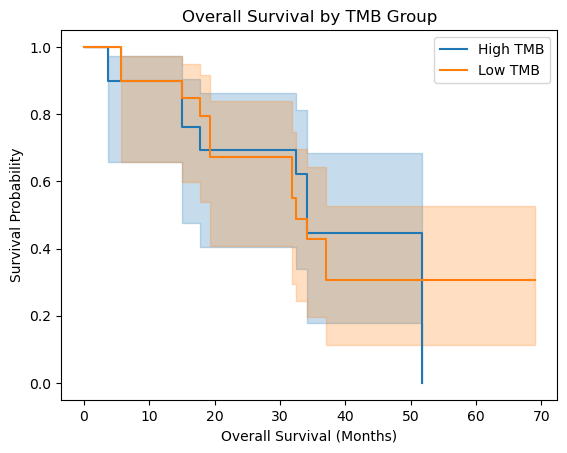

In [13]:
kmf = KaplanMeierFitter()

# Separate TMB groups
high_tmb = survival_df["TMB Group"] == "High TMB"
low_tmb = survival_df["TMB Group"] == "Low TMB"

# Fit high TMB group
kmf.fit(
    durations=survival_df.loc[
        high_tmb,
        "Overall Survival (Months)"
    ],
    event_observed=survival_df.loc[
        high_tmb,
        "Event"
    ],
    label="High TMB"
)

ax = kmf.plot()

# Fit low TMB group
kmf.fit(
    durations=survival_df.loc[
        low_tmb,
        "Overall Survival (Months)"
    ],
    event_observed=survival_df.loc[
        low_tmb,
        "Event"
    ],
    label="Low TMB"
)

kmf.plot(ax=ax)

plt.title("Overall Survival by TMB Group")
plt.xlabel("Overall Survival (Months)")
plt.ylabel("Survival Probability")
plt.show()

# Add the log-rank test

The Kaplan-Meier curves show the survival distributions, but you also want to statistically compare them.

In [14]:
from lifelines.statistics import logrank_test

In [15]:
results = logrank_test(
    survival_df.loc[
        high_tmb,
        "Overall Survival (Months)"
    ],
    survival_df.loc[
        low_tmb,
        "Overall Survival (Months)"
    ],
    event_observed_A=survival_df.loc[
        high_tmb,
        "Event"
    ],
    event_observed_B=survival_df.loc[
        low_tmb,
        "Event"
    ]
)

print("Log-rank test statistic:", results.test_statistic)
print("p-value:", results.p_value)

Log-rank test statistic: 0.005842851841460956
p-value: 0.9390702012801905


- The p-value will help evaluate whether there is evidence of a difference in survival between the two TMB groups.
- frame the results as exploratory and avoid overinterpreting a nonsignificant result due to small sample size

# Checking how unique samples correspond to unique patients 

In [16]:
print(df["Patient ID"].nunique())

20


In [17]:
print(
    df["Number of Samples Per Patient"].value_counts()
)

Number of Samples Per Patient
2    36
3     6
Name: count, dtype: int64


In [18]:
print(
    df.groupby("Patient ID").size().value_counts()
)

2    18
3     2
Name: count, dtype: int64


# Figuring out why each patient has multiple samples 

In [19]:
df[
    [
        "Patient ID",
        "Sample ID",
        "Sample Type",
        "Sample Class",
        "Primary Tumor Site",
        "Metastatic Site",
        "TMB (nonsynonymous)",
        "Overall Survival (Months)",
        "Overall Survival Status"
    ]
].sort_values("Patient ID")

,Patient ID,Sample ID,Sample Type,Sample Class,Primary Tumor Site,Metastatic Site,TMB (nonsynonymous),Overall Survival (Months),Overall Survival Status
0,P-0006113,P-0006113-T01-IM5,Primary,Tumor,Soft Tissue,NaN,0.978720,37.085,1:DECEASED
1,P-0006113,P-0006113-T02-IM6,Metastasis,Tumor,Soft Tissue,Soft Tissue,0.864698,37.085,1:DECEASED
2,P-0013120,P-0013120-T04-IM6,Metastasis,Tumor,Soft Tissue,Lymph Node,0.000000,31.890,1:DECEASED
3,P-0013120,P-0013120-T06-IM6,Metastasis,Tumor,Unknown,Peritoneal Implant,0.000000,31.890,1:DECEASED
4,P-0018770,P-0018770-T02-IM6,Primary,Tumor,Mediastinum,NaN,0.864698,32.449,1:DECEASED
5,P-0018770,P-0018770-T04-IM6,Metastasis,Tumor,Diaphragm,NaN,2.594094,32.449,1:DECEASED
6,P-0019531,P-0019531-T01-IM6,Primary,Tumor,Soft Tissue,NaN,0.000000,69.008,0:LIVING
7,P-0019531,P-0019531-T05-IM6,Local Recurrence,Tumor,Soft Tissue,NaN,0.864698,69.008,0:LIVING
9,P-0022317,P-0022317-T03-IM6,Primary,Tumor,Soft Tissue,NaN,0.000000,5.688,1:DECEASED
8,P-0022317,P-0022317-T02-IM6,Metastasis,Tumor,Soft Tissue,Lymph Node,0.000000,5.688,1:DECEASED


In [20]:
df.groupby("Patient ID")[
    "TMB (nonsynonymous)"
].agg(
    ["count", "min", "max", "mean"]
)

,count,min,max,mean
Patient ID,,,,
P-0006113,2,0.864698,0.978720,0.921709
P-0013120,2,0.000000,0.000000,0.000000
P-0018770,2,0.864698,2.594094,1.729396
P-0019531,2,0.000000,0.864698,0.432349
P-0022317,2,0.000000,0.000000,0.000000
P-0028971,2,0.864698,1.729396,1.297047
P-0033453,2,2.594094,3.281389,2.937742
P-0035844,3,0.864698,2.461042,1.928927
P-0045478,2,0.000000,0.000000,0.000000


In [1]:
import sys
print(sys.executable)

/users/PAS3421/emmafischels/.conda/envs/rms-tmb-capstone/bin/python
